In [3]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
from mount_drive import mount_s_drive

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from sklearn.datasets import make_classification


2025-04-12 23:27:09.364158: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-12 23:27:09.366593: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-12 23:27:09.374002: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744514829.386609     264 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744514829.390395     264 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-12 23:27:09.405493: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [10]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.feature_selection import VarianceThreshold

from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.impute import KNNImputer
from eICUUtil import *
from sklearn.decomposition import PCA

In [23]:
myTreatmentColumn = 'both_hypothermia'
myPredictorsDf, X_train, X_test, y_train, y_test = getTrainTestFunctions(aPredictedColumn = 'DeathAtDischarge', 
                                                                         aTreatmentColumn = myTreatmentColumn, 
                                                                         aDropColumns=['Hypothermia', 'treatment_hypothermia', 'treatment_therapy for controlling cerebral perfusion pressure', 
                                                                                         'treatment_neurologic', 'treatment_neuromuscular blocking agent', 'treatment_subcutaneous'], 
                                                                         aSkipTemp = True) 

/home/idies/workspace/Storage/hkim171/ACCM_PMAP_SEPSIS/mbranda1/ttmhte/eICU/eICUUtil.py:6: DtypeWarning: Columns (2059,2070,2081,2083,2084,2089,2095,2099,2108,2119,2130,2132,2133,2138,2144,2148,2305,2307) have mixed types. Specify dtype option on import or set low_memory=False.
  myPredictorsDf = pd.read_csv('eICUPredictorsDiag.csv')


In [33]:
def getCovariatePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = PCA(0.99)
        )
def getVariancePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = VarianceThreshold(0.01)
        )

In [34]:
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    myPreprocessor.set_output(transform="pandas")
    myImputer = KNNImputer(n_neighbors=50)
    myImputer.set_output(transform="pandas")
    myBinaryColumns  = ['bin__' + x for x in myBinaryColumns]
    myCovariates = getCovariatePreprocessor(['keep__bin__' + myTreatmentColumn])
    myCovariates.set_output(transform="pandas")
    myVariance = getVariancePreprocessor(['bin__' + myTreatmentColumn])
    myVariance.set_output(transform="pandas")
    return [('preprocessor', myPreprocessor),  ('variance', myVariance), ('imputer', myImputer), ('covariates', myCovariates)]

In [35]:
# X_train = X_train.loc[:, X_train.isnull().mean() < 0.5]
# X_test = X_test[X_train.columns]

In [27]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train))
X_train_transf = myPipeline.fit_transform(X_train, y_train)
X_test_transf = myPipeline.transform(X_test)
X_train_transf = pd.DataFrame(X_train_transf, columns = myPipeline.get_feature_names_out())
X_test_transf = pd.DataFrame(X_test_transf, columns = myPipeline.get_feature_names_out())

In [28]:
X_train_transf.shape

(2005, 526)

In [31]:
model = keras.Sequential([
    keras.Input(shape=(X_train_transf.shape[1],)),  
    layers.Dense(32, activation='relu'), 
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') 
])
# from tensorflow.keras.callbacks import EarlyStopping

# early_stopping = EarlyStopping(
#     monitor='loss',  # Metric to track
#     patience=10,          # Number of epochs to wait before stopping
#     restore_best_weights=True  # Restore the best model weights
# )

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name="roc_auc")])


In [32]:
history = model.fit(X_train_transf, y_train.reset_index().drop(columns='index'), epochs=15, batch_size=32, validation_data=(X_test_transf, y_test.reset_index().drop(columns='index')))#, callbacks=[early_stopping])

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5397 - loss: 0.8355 - roc_auc: 0.5352 - val_accuracy: 0.6895 - val_loss: 0.6249 - val_roc_auc: 0.7394
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6517 - loss: 0.6311 - roc_auc: 0.7226 - val_accuracy: 0.7116 - val_loss: 0.6054 - val_roc_auc: 0.7712
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7021 - loss: 0.5963 - roc_auc: 0.7727 - val_accuracy: 0.7221 - val_loss: 0.5965 - val_roc_auc: 0.7816
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7412 - loss: 0.5224 - roc_auc: 0.8191 - val_accuracy: 0.7128 - val_loss: 0.6044 - val_roc_auc: 0.7800
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7676 - loss: 0.4702 - roc_auc: 0.8560 - val_accuracy: 0.7116 - val_loss: 0.6120 - val_roc_auc: 0.7803
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7884 - loss: 0.4503 - roc_auc: 0.8700 - val_accuracy: 0.7093 - val_loss: 0.6188 - val_roc_auc: 0.7807
Epoc

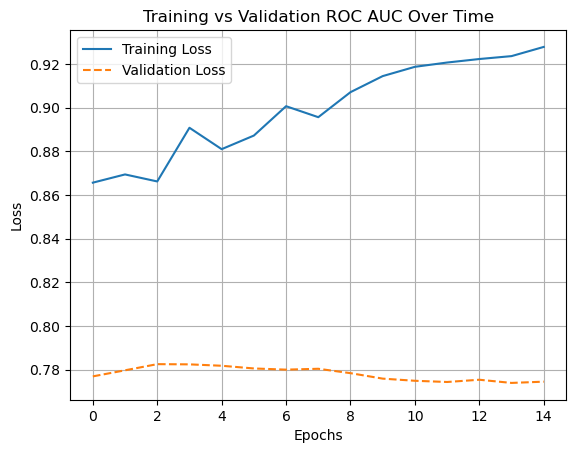

In [11]:
# Extract loss values
train_loss = history.history['roc_auc']
val_loss = history.history['val_roc_auc']

# Plot training & validation loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss', linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation ROC AUC Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
y_pred_probs = model.predict(X_test_transf)  # Probabilities

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
ROC AUC Score: 0.7743


In [13]:
y_pred_probs.T[0, :]

array([1.59149960e-01, 5.62573314e-01, 6.47602499e-01, 9.98364031e-01,
       1.26389191e-01, 9.30932641e-01, 5.29183269e-01, 7.12995410e-01,
       9.81588423e-01, 6.01633405e-03, 5.31229973e-02, 9.63515937e-01,
       8.70625317e-01, 7.57252753e-01, 6.63060009e-01, 7.14632154e-01,
       3.66104066e-01, 8.32079910e-03, 4.50596601e-01, 2.37630829e-02,
       6.02354050e-01, 9.99641120e-01, 3.06951255e-02, 9.42818403e-01,
       9.64329064e-01, 8.88393819e-01, 6.81880355e-01, 7.99259961e-01,
       2.96421736e-01, 5.24051070e-01, 9.99977767e-01, 5.09457588e-02,
       3.10202211e-01, 7.11345896e-02, 3.64660203e-01, 3.38860229e-02,
       8.55605960e-01, 4.93220389e-01, 2.52469808e-01, 2.85250038e-01,
       1.40854836e-01, 9.78561163e-01, 9.75010991e-01, 4.15007919e-01,
       3.53567302e-01, 8.28355849e-01, 9.99078751e-01, 9.46180582e-01,
       8.53592932e-01, 9.94391918e-01, 7.40778327e-01, 9.82046306e-01,
       4.43191558e-01, 9.42532539e-01, 5.77720225e-01, 4.83556241e-01,
      

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 976us/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step
Optimization terminated successfully.
         Current function value: 0.680034
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.679672
         Iterations 4
Likelihood ratio of test results:
Chi square statistic: 1.451076623766312
p-value: 0.4840639214457093
Degress of freedom: 2.0
No interaction                            Logit Regression Results                           
Dep. Variable:       DeathAtDischarge   No. Observations:                 2005
Model:                          Logit   Df Residuals:                     2001
Method:                           MLE   Df Model:                            3
Date:                Sat, 15 Mar 2025   Pseudo R-squ.:                0.009076
Time:                        15:09:16   Log-Likelihood:                -1363.5
converged:                       True   LL-Null:                       -1376.0
Covariance Type:    

0.4840639214457093

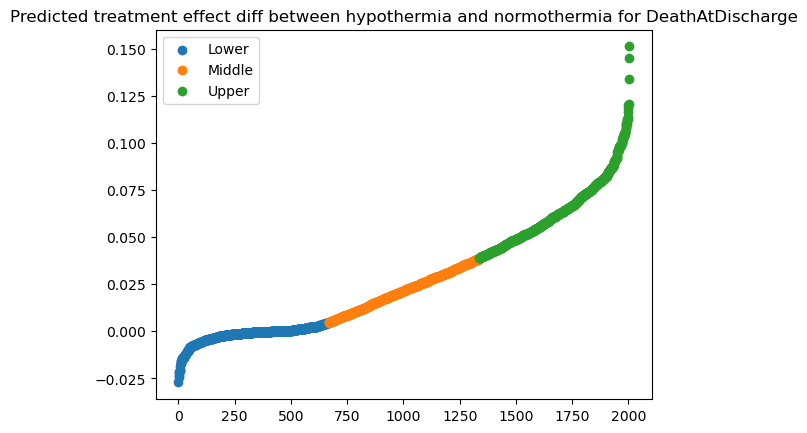

In [14]:
getTreatmentEffectDiff(aX = X_train_transf, aY = y_train.reset_index().drop(columns='index'), aModel = model, \
                       aCategory = 'DeathAtDischarge', aGroup = 'keep__bin__both_hypothermia', aUseNeuralNetwork = True, aByGroup = True)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step
Optimization terminated successfully.
         Current function value: 0.681020
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.680220
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 1.374567027096873
p-value: 0.24102875248990907
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:       DeathAtDischarge   No. Observations:                  860
Model:                          Logit   Df Residuals:                      857
Method:                           MLE   Df Model:                            2
Date:                Mon, 10 Mar 2025   Pseudo R-squ.:                0.007797
Time:                        08:59:45   Log-Likelihood:                -585.68
converged:                       True   LL-Null:                       -590.28
Covariance Type:   

0.24102875248990907

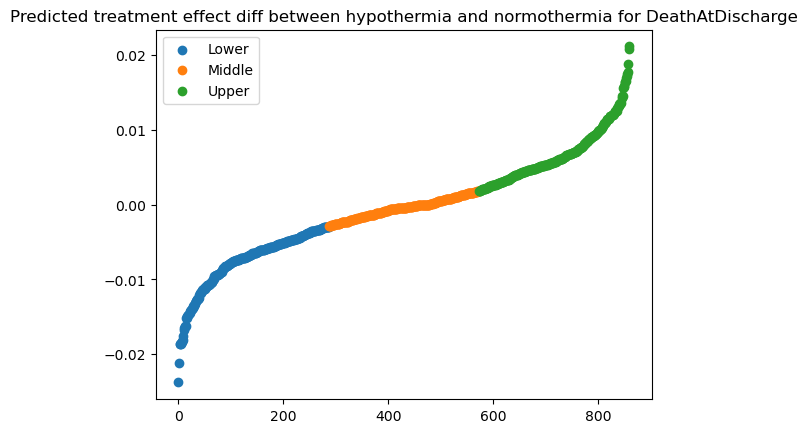

In [90]:
getTreatmentEffectDiff(aX = X_test_transf, aY = y_test.reset_index().drop(columns='index'), aModel = model, \
                       aCategory = 'DeathAtDischarge', aGroup = 'keep__bin__both_hypothermia', aUseNeuralNetwork = True, aByGroup = False)

In [87]:
myGroup = myNewDf.groupby(['predicted_effect_group', myTreatment]).agg({myPredicted:'sum', 'index':'count'})
myGroup = myGroup.reset_index()
myGroup['percent'] = myGroup[myPredicted] / myGroup['index']
myGroup
# does not mean anything because you don't know the baseline effect

NameError: name 'myNewDf' is not defined